<a href="https://colab.research.google.com/github/iestleija/4808-Programacion/blob/Unidad3/Unidad3/Practices/226229_01_Semana11.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Maestría en Inteligencia Artificial y Analítica de Datos

## Programación para Analítica Descriptiva y Predictiva - Marzo 2025
## Práctica: Regresión Lineal Múltiple
---


## Datos del Estudiante

*   Apellidos y Nombre: Ismael Estrada Leija
*   Matrícula: 266229

---



##  Objetivo de aprendizaje
Al finalizar esta práctica, el estudiante será capaz de **aplicar regresión lineal múltiple utilizando Scikit-Learn para modelar la relación entre varias variables independientes y una variable dependiente**, verificar los supuestos del modelo, interpretar los coeficientes, analizar la correlación entre predictores y evaluar el rendimiento del modelo utilizando métricas como el MSE, RMSE y R².

Datos
Trabajarás con el archivo `advertising.csv`, que contiene información sobre el gasto publicitario en diferentes medios y las ventas obtenidas:

-`TV`: inversión en publicidad televisiva.

-`Radio`: inversión en publicidad en radio.

-`Newspaper`: inversión en publicidad en periódicos.

`Sales`: ventas del producto (variable dependiente).

In [59]:
from google.colab import drive
drive.mount('/content/drive')
def print_bold(msg):
    print("\n\033[1m" + msg + "\033[0m")
advertising_file_path = '/content/drive/MyDrive/4808-programacion/semana11/Practica01/advertising.csv';

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Parte 1: Carga de datos y bibliotecas
1. Importa las bibliotecas necesarias.
2. Carga el archivo `advertising.csv`.
3. Muestra las primeras filas del dataframe.
4. Describe estadísticamente las variables.

In [60]:
# Tu código aquí

# 1. Importación de librerías

import pandas as pd
# import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
# from sklearn.model_selection import train_test_split
# from sklearn.linear_model import LinearRegression
# from sklearn.metrics import mean_squared_error, r2_score


# 2. Carga de dataset advertising.csv

ad_df =pd.read_csv(advertising_file_path)

# 3. Muestra las primeras filas del dataframe.
print_bold("Muestra las primeras filas del dataframe.")
print(ad_df.head())

# 4. Describe estadísticamente las variables.
print_bold("Describe estadísticamente las variables.")
ad_df.describe()



Muestra las primeras filas del dataframe.
      TV  Radio  Newspaper  Sales
0  230.1   37.8       69.2   22.1
1   44.5   39.3       45.1   10.4
2   17.2   45.9       69.3   12.0
3  151.5   41.3       58.5   16.5
4  180.8   10.8       58.4   17.9

Describe estadísticamente las variables.


,TV,Radio,Newspaper,Sales
count,200.000000,200.000000,200.000000,200.000000
mean,147.042500,23.264000,30.554000,15.130500
std,85.854236,14.846809,21.778621,5.283892
min,0.700000,0.000000,0.300000,1.600000
25%,74.375000,9.975000,12.750000,11.000000
50%,149.750000,22.900000,25.750000,16.000000
75%,218.825000,36.525000,45.100000,19.050000
max,296.400000,49.600000,114.000000,27.000000


## Parte 2: Análisis exploratorio de los datos
### 2.1  Análisis de la Relación Lineal entre la variable dependiente y las independientes
1. Grafica dispersión entre cada variable independiente (`TV`, `Radio`, `Newspaper`) y `Sales`. Usa también regplot.
2. Interpreta visualmente la relación entre variables.

In [61]:
# Agrupamiento de variables

# variables independientes
X = ad_df[['TV', 'Radio', 'Newspaper']]

# variable dependiente
y = ad_df['Sales']

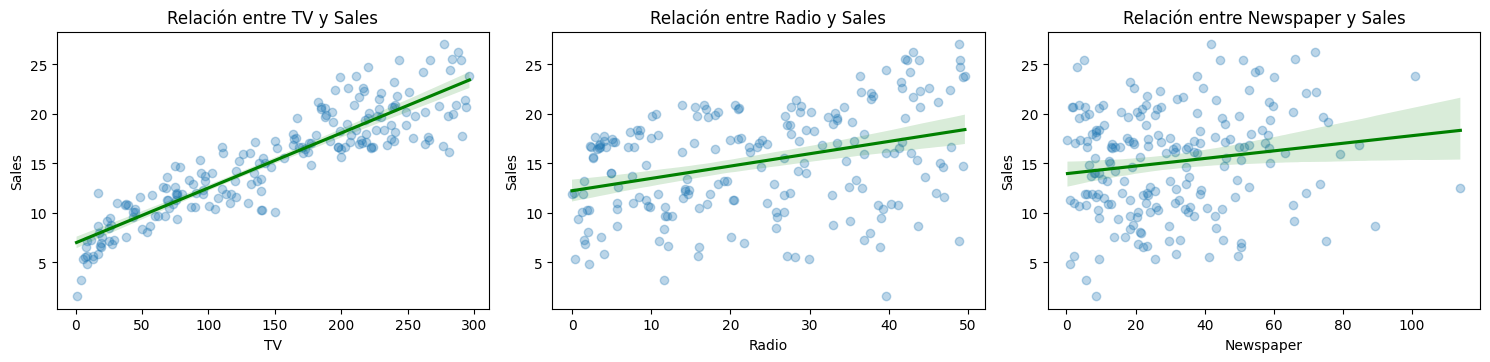

In [62]:
# Gráficos de dispersión
plt.figure(figsize=(15, 10))
for i, col in enumerate(X.columns):
    plt.subplot(3, 3, i + 1)
    sns.regplot(x=X[col], y=y, scatter_kws={'alpha':0.3}, line_kws={'color': 'green'})
    plt.title(f"Relación entre {col} y {y.name}")

plt.tight_layout()
plt.show()

### 🔍 **Análisis de la Relación entre Variables Independientes y Sales**  
#### 📺 **1. Relación entre TV (Inversión en TV) y Sales:**  
- **Tendencia:** 🟢 **Positiva y fuerte**  
- La línea roja de regresión muestra una **clara tendencia ascendente**, indicando que a mayor inversión en publicidad televisiva, mayores son las ventas. Los puntos se agrupan relativamente cerca de la línea.
- **Conclusión:** La inversión en TV es un **predictor fuerte** de las ventas.

---

#### 📻 **2. Relación entre Radio (Inversión en Radio) y Sales:**  
- **Tendencia:** 🟡 **Positiva y moderada**  
- La línea de regresión tiene una **pendiente positiva**, lo que sugiere que a mayor inversión en radio, tienden a aumentar las ventas. Sin embargo, la dispersión de los puntos alrededor de la línea es mayor que en el caso de la TV.
- **Conclusión:** La inversión en Radio es un **predictor moderado** de las ventas.

---

#### 📰 **3. Relación entre Newspaper (Inversión en Periódicos) y Sales:**  
- **Tendencia:** 🔴 **Débil o Nula**  
- La línea de regresión es **casi plana o tiene una pendiente muy leve**, y los puntos están **muy dispersos** alrededor de ella. Esto indica que no hay una relación lineal clara entre la inversión en periódicos y las ventas.
- **Conclusión:** La inversión en periódicos **no parece ser un predictor relevante** de las ventas en este modelo lineal.

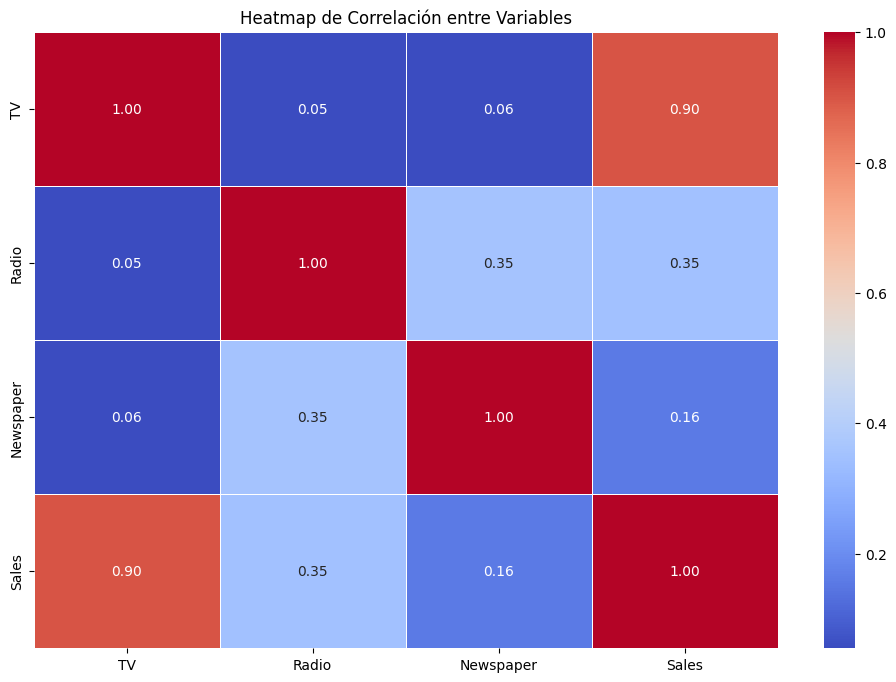

In [63]:
# Correlación y heatmap

plt.figure(figsize=(12, 8))
correlation_matrix = ad_df.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', cbar=True, linewidths=0.5)
plt.title("Heatmap de Correlación entre Variables")
plt.show()

### 🔍 Análisis del mapa de calor entre Variables Dependientes y Variable Objetivo

Considerando irrelevante para este anáilsis la correlación entre las variables independientes, la variable objetivo ``ventas`` guarda una coherencia fuerte con el análisis visto previamente en los diagramas de dispersión, tal que, la variable independiente con mayor influencia en las ventas es la inversión en publicidad ``televisiva`` seguida por una moderada respuesta de las ventas hacia la inversión en anuncios en ``radio``. Por su parte el gasto en impresiones ``periodísticas`` tiene un impacto casi nulo en el aumento de las ventas.

## Parte 3. Multicolinealidad
1. Calcula el VIF (Variance Inflation Factor) para cada predictor.
2. Crea un diagrama de barras  para mostrar el  VIF
3. Interpreta si hay multicolinealidad:
- ¿Alguna variable tiene un VIF mayor a 5 o mayor a 10?
- ¿Qué implicaciones tiene esto para el modelo?

In [64]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

#Multicolinealidad
vif_source = X;
vif_source = add_constant(vif_source)
vif_data = pd.DataFrame()
vif_data['Variable'] = X.columns
vif_data['VIF'] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

print_bold("\n### Análisis de Multicolinealidad ###")
print(vif_data)



### Análisis de Multicolinealidad ###
    Variable       VIF
0         TV  2.486772
1      Radio  3.285462
2  Newspaper  3.055245


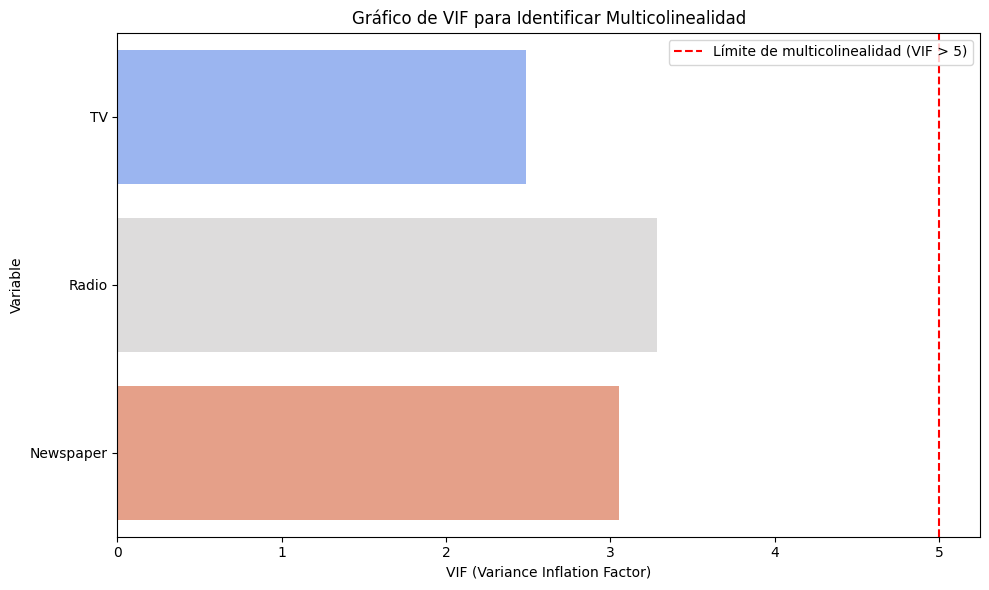

In [65]:
# Visualización de la colinealidad.

plt.figure(figsize=(10, 6))
sns.barplot(x='VIF', y='Variable', data=vif_data, palette='coolwarm', hue='Variable', legend=False)
plt.axvline(x=5, color='red', linestyle='--', label='Límite de multicolinealidad (VIF > 5)')
plt.xlabel('VIF (Variance Inflation Factor)')
plt.title('Gráfico de VIF para Identificar Multicolinealidad')
plt.legend()
plt.tight_layout()
plt.show()

### 🔍 Análisis de Colinealidad mediante el Factor de Inflación de Varianza
Para este caso todos los valores VIF están **por debajo de 5**. Esto sugiere que no hay un problema significativo de multicolinealidad entre las variables predictoras (TV, Radio, Newspaper) en este modelo. Por lo tanto, no es necesario eliminar ninguna variable basándose en este criterio.

🔍 **Análisis del VIF**
### Resultados de la Tabla de VIF
| **Variable**   | **VIF**   | **Diagnóstico de Multicolinealidad**     |
|----------------|-----------|-----------------------------------------|
| `TV`        | 2.487 | ✅ **Aceptable**                    |
| `Radio`       | 3.285  | ✅ **Aceptable**                        |
| `Newspaper`     | 3.055  | ✅ **Aceptable**                        |


## Parte 4: Construcción del Modelo (Todas las variables Independientes), Evaluación


### 4.1 Entrenamiento del Modelo (Todas las Variables Independientes)

1. Entrena un modelo de regresión lineal múltiple usando TV, Radio y Newspaper como variables independientes.
2. Imprime el intercepto y los coeficientes del modelo.
3. Interpreta cada uno:
¿Qué significa cada uno de los coeficientes  en términos de ventas?

In [66]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler

# Entrenamiento del Modelo (Todas las Variables Independientes)

# Ajustar el modelo a regresion lineal multiple
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
model = LinearRegression()
model.fit(X_scaled,y)

LinearRegression()

In [67]:
# Obtener la funcion con los parámetros del mnodelo
coefficients = model.coef_
intercept = model.intercept_

print_bold("\n### Análisis del Modelo : Parámetros (\u03b8) ###")
print(f"Coeficientes estimados (W): {coefficients}")
print(f"Término independiente estimado (b): {intercept}")
#######################################################
equation = f"{y.name} = {intercept} "
for i, coef in enumerate(coefficients):
  equation += f"+ ({coef} * {X.columns[i]}) "

print_bold("\n### Análisis del Modelo : Ecuación del Modelo ###")
equation #se obtiene el modelo con los coeficientes



### Análisis del Modelo : Parámetros (θ) ###
Coeficientes estimados (W): [4.66270025 1.58465027 0.00729187]
Término independiente estimado (b): 15.130500000000001


### Análisis del Modelo : Ecuación del Modelo ###


'Sales = 15.130500000000001 + (4.662700245086694 * TV) + (1.5846502733236385 * Radio) + (0.0072918683037688226 * Newspaper) '

### 🔍 **Interpretación de la Ecuación del Modelo de Regresión Lineal (Coeficientes Escalados)**

La ecuación obtenida del modelo de regresión lineal múltiple con los coeficientes **escalados** es:

**`Sales = 15.13 + (4.66 * TV_scaled) + (1.58 * Radio_scaled) + (0.01 * Newspaper_scaled)`**

Donde:

*   **`Sales`**: Es la variable dependiente, que representa las ventas esperadas.

*   **`15.13 (Intercepto Escalado)`**: Representa el valor promedio de las ventas cuando todas las inversiones en publicidad (TV, Radio, Newspaper) son cero en términos de sus valores escalados (es decir, cuando cada variable independiente está en su media). En un modelo con variables predictoras estandarizadas, el intercepto suele ser la media de la variable dependiente.

*   **`4.66 (Coeficiente de TV Escalado)`**: Indica que, por cada **una desviación estándar adicional** invertida en publicidad televisiva (TV), las ventas se incrementan en aproximadamente **4.66 desviaciones estándar**, manteniendo constantes las inversiones en Radio y Newspaper. Esto sugiere un impacto muy fuerte y positivo.

*   **`1.58 (Coeficiente de Radio Escalado)`**: Sugiere que, por cada **una desviación estándar adicional** invertida en publicidad de radio, las ventas aumentan en aproximadamente **1.58 desviaciones estándar**, manteniendo constantes las otras variables. Esto indica un impacto positivo y moderado.

*   **`0.01 (Coeficiente de Newspaper Escalado)`**: Muestra que, por cada **una desviación estándar adicional** invertida en publicidad de periódicos, las ventas aumentan en apenas **0.01 desviaciones estándar**, manteniendo constantes las otras variables. Este coeficiente, al ser tan cercano a cero, refuerza la conclusión anterior de que la inversión en periódicos tiene un impacto insignificante o nulo en las ventas.

---

**Conclusión Clave para la Influencia Relativa:**

Entre las variables escaladas, **TV** tiene el mayor coeficiente (4.66), lo que indica que, para un cambio equivalente de una desviación estándar en la inversión, la publicidad en TV tiene el **mayor impacto relativo** en el cambio de las ventas en comparación con Radio y Newspaper. Radio también tiene un impacto significativo, mientras que Newspaper es prácticamente irrelevante.

In [98]:
# 10. Realizar predicciones con el modelo
y_pred = model.predict(X_scaled)

# 11. Comparar los primeros valores reales con las predicciones
comparison = pd.DataFrame({
    'Valor Real': y.head(),
    'Predicción': y_pred[:5]  # Primeras 5 predicciones
})

print_bold("Comparación entre las predicciones y los valores reales:")
print(comparison)


Comparación entre las predicciones y los valores reales:
   Valor Real  Predicción
0        22.1   21.220972
1        10.4   11.268248
2        12.0   10.496209
3        16.5   17.312447
4        17.9   15.644137


### 4.2 Normalidad de los residuos

1. Calcula los residuos: residuos = y - y_pred.

2. Grafica un histograma con KDE de los residuos.

3. ¿Los residuos parecen distribuirse normalmente?

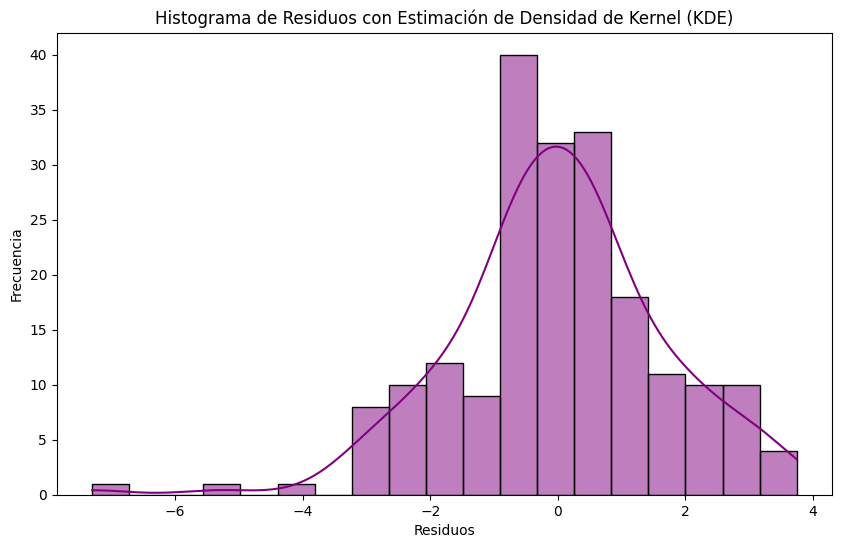

In [69]:
#Normalidad de los residuos

# 1. Calcula los residuos
residuals = y - y_pred

# 2. Grafica un histograma con KDE de los residuos.
plt.figure(figsize=(10, 6))
sns.histplot(residuals, kde=True, color='purple')
plt.title('Histograma de Residuos con Estimación de Densidad de Kernel (KDE)')
plt.xlabel('Residuos')
plt.ylabel('Frecuencia')
plt.show()

### 🔍 **Interpretación del Histograma de Residuos**

Al observar el histograma de residuos con la curva KDE, podemos evaluar si los residuos parecen seguir una distribución normal.

En este caso, se observa que los residuos están aproximadamente centrados en cero y su distribución se asemeja a una campana, aunque con algunas desviaciones. Esto sugiere que el supuesto de normalidad de los residuos se cumple en gran medida, lo cual es favorable para la validez de nuestro modelo de regresión lineal.

### 4.3. Homocedasticidad

1. Grafica los residuos contra los valores predichos.
2. ¿Observas patrones? ¿Los residuos se dispersan aleatoriamente?

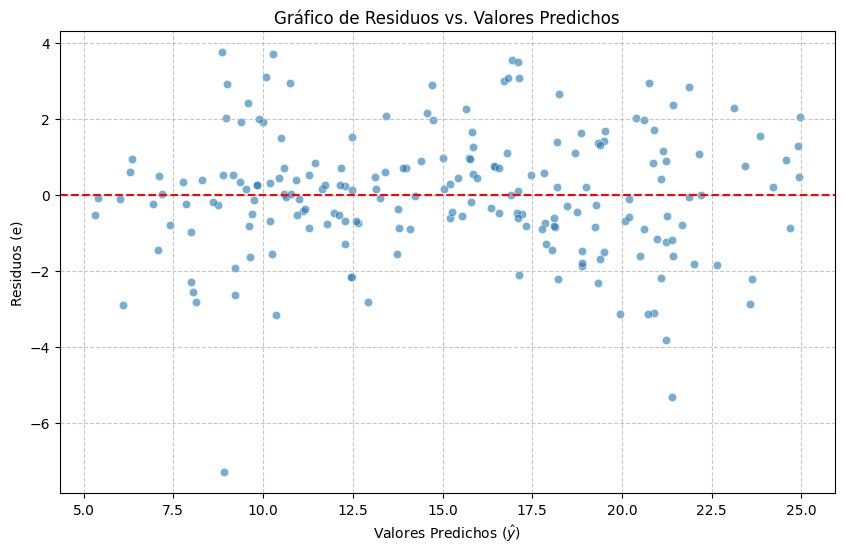

In [70]:

# 1. Grafica los residuos contra los valores predichos.
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_pred, y=residuals, alpha=0.6)
plt.axhline(y=0, color='red', linestyle='--')
plt.title('Gráfico de Residuos vs. Valores Predichos')
plt.xlabel(r'Valores Predichos ($\hat{y}$)')
plt.ylabel('Residuos (e)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

### 🔍 **Interpretación del Gráfico de Residuos vs. Valores Predichos (Homocedasticidad)**

Al observar la gráfica de residuos contra los valores predichos, buscamos la ausencia de patrones claros. La homocedasticidad, uno de los supuestos clave de la regresión lineal, implica que la varianza de los errores (residuos) es constante a lo largo de todos los niveles de las variables predictoras. (Khan, 2025)

En nuestro caso, observamos que los residuos parecen distribuirse de manera aleatoria alrededor de la línea cero, sin patrones evidentes de aumento o disminución de la dispersión a medida que aumentan los valores predichos. Esto sugiere que el supuesto de homocedasticidad se cumple razonablemente bien para este modelo.

### 4.4 Q-Q Plot

1. Graficar el Q-Q Plot
2. Interpreta el gráfico: a) Si los puntos se alinean aproximadamente sobre la línea diagonal, los residuos siguen una distribución normal, b) Desviaciones sistemáticas indican asimetría o colas pesadas.

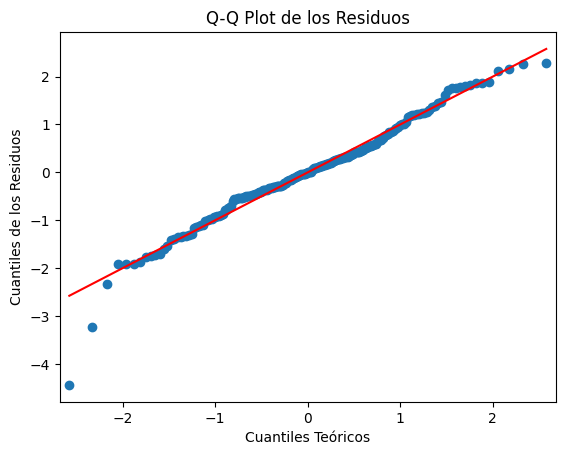

In [75]:
#Q-Q Plot
import statsmodels.api as sm
import scipy.stats as stats
import matplotlib.pyplot as plt

# Q-Q Plot de los residuos
sm.qqplot(residuals, line='s', fit=True)
plt.title('Q-Q Plot de los Residuos')
plt.xlabel('Cuantiles Teóricos')
plt.ylabel('Cuantiles de los Residuos')
plt.show()

 ### 🔍 **Interpretación del Gráfico Cuantil por Cuantil**

 Podemos ver que la mayoría de los puntos se alinean muy de cerca con la línea diagonal. Esto es una fuerte indicación de que los residuos de nuestro modelo siguen una distribución aproximadamente normal.(Saxena, 2026)

### 4.5. Evaluación del Modelo

1. Calcula las métricas: a) MSE (error cuadrático medio), b) RMSE (raíz del error cuadrático medio), c) R² (coeficiente de determinación)

2. ¿Qué nos dicen estas métricas sobre el ajuste del modelo?


In [80]:
#Evaluación del Modelo
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# 1. Calcular las métricas
mse = mean_squared_error(y, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y, y_pred)

print_bold("\n### Evaluación del Modelo ###")
print(f"MSE (Error Cuadrático Medio): {mse:.2f}")
print(f"RMSE (Raíz del Error Cuadrático Medio): {rmse:.2f}")
print(f"R² (Coeficiente de Determinación): {r2:.2f}")



### Evaluación del Modelo ###
MSE (Error Cuadrático Medio): 2.71
RMSE (Raíz del Error Cuadrático Medio): 1.64
R² (Coeficiente de Determinación): 0.90


 ### 🔍 **Interpretación de la Evaluación del Modelo**
Los factores evaluados se perciben como sigue:

**MSE(Error cuadrático medio)=2.71:** Denota un error del modelo muy pequeño respecto a las ventas.

**RMSE (Raíz del error cuadrático medio) = 1.64:** Indica un error muy bajo respecto a las ventas, ahora en las unidades originales de la variable.

**$R^2$(Coeficiente de detrminación)= 0.90:** Es una razón mas compleja que nos muestra que porcentaje de la varianza de la variable dependiente es explicada por las variables independientes. El resultado encontrado soporta la buena capacidad predictiva de nuestro modelo.


### 4.6. Visualización de Predicciones

1. Crea un gráfico comparando Sales reales vs Sales predichas.

2. Puedes usar plt.scatter(y_true, y_pred) para evaluar visualmente el ajuste.
3.¿Qué observas?¿Qué observas? ¿Qué información puedes obtener de esta gráfica?

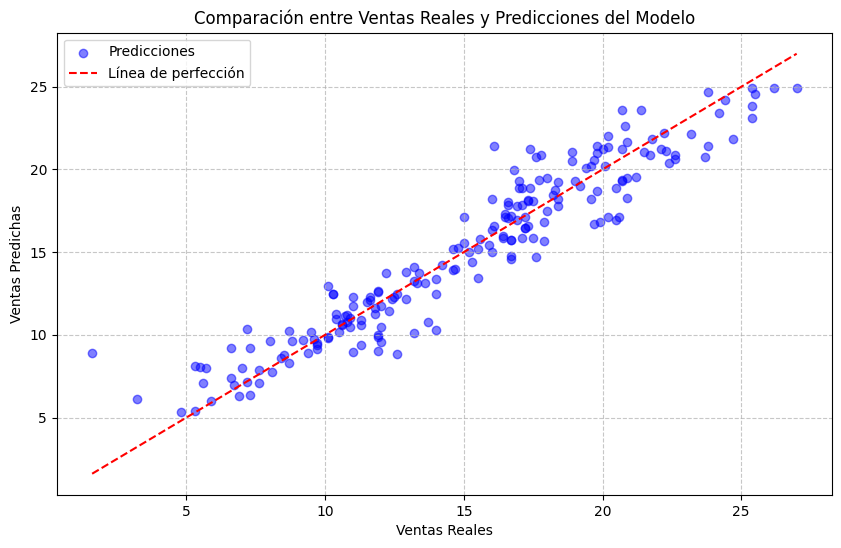

In [81]:
#Visualización de las Predicciones
plt.figure(figsize=(10, 6))
plt.scatter(y, y_pred, alpha=0.5, color='blue', label='Predicciones')
plt.plot([y.min(), y.max()], [y.min(), y.max()], color='red', linestyle='--', label='Línea de perfección')
plt.title("Comparación entre Ventas Reales y Predicciones del Modelo")
plt.xlabel("Ventas Reales")
plt.ylabel("Ventas Predichas")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

 ### 🔍 **Interpretación de la Visualización de Predicciones**
 Podemos ver en primer plano la línea de perfección, donde las ventas predichas por el modelo serían exactamente iguales a las reales. Los puntos azules que representan la predicción se dispersan muy cercanos a esa lína por lo cual podemos considerar una operación precisa del modelo.
 No existen patrones diversos a la línea por lo que se refuerza la idea que el modelo es apropiado.
 En resumen, el modelo presenta un buen ajuste a los datos.

### 4.7 Verificar el impacto de los atributos en el modelo

1. Ajusta el modelo usando statsmodels en lugar de scikit-learn para obtener los valores p.
2. Interpreta los resultados:

 - Observa los valores P>|t| en la tabla de salida.

 - ¿Qué variables tienen p-value menores a 0.05?

 - ¿Cuál es la conclusión sobre esas variables?


In [83]:
#P-values
import statsmodels.api as sm

# Para statsmodels, necesitamos añadir explícitamente una constante para el intercepto
X_scaled_sm = sm.add_constant(X_scaled)

# Crear y ajustar el modelo OLS (Ordinary Least Squares)
model_sm = sm.OLS(y, X_scaled_sm)
results_sm = model_sm.fit()

print_bold("\n### Resumen del Modelo (Statsmodels) para P-values ###")
print(results_sm.summary())



### Resumen del Modelo (Statsmodels) para P-values ###
                            OLS Regression Results                            
Dep. Variable:                  Sales   R-squared:                       0.903
Model:                            OLS   Adj. R-squared:                  0.901
Method:                 Least Squares   F-statistic:                     605.4
Date:                Mon, 27 Apr 2026   Prob (F-statistic):           8.13e-99
Time:                        02:55:56   Log-Likelihood:                -383.34
No. Observations:                 200   AIC:                             774.7
Df Residuals:                     196   BIC:                             787.9
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------

### 🔍 **Interpretación de los Valores p (P-values)**

Al observar la tabla de resultados de `statsmodels` (columna `P>|t|`), podemos resumir la significancia estadística de cada variable:

| Variable   | P-value | Significancia Estadística |
|:-----------|:--------|:--------------------------|
| `const`    | 0.000   | Significativo (p < 0.05)  |
| `x1` (TV)  | 0.000   | Significativo (p < 0.05)  |
| `x2` (Radio)| 0.000   | Significativo (p < 0.05)  |
| `x3` (Newspaper)| 0.954   | No Significativo (p > 0.05)|

**Conclusión:** Las inversiones en **Televisión** y **Radio** son estadísticamente significativas para predecir las ventas, lo que significa que tienen un impacto real y no aleatorio. Por el contrario, la inversión en **Periódicos** no muestra una relación estadísticamente significativa con las ventas en este modelo, sugiriendo un impacto insignificante.

##Parte 5:  Construcción del Modelo (sin Multicolinealidad), Evaluación

En el caso de que hayas detectado variables con multicolinealidad. Elimina aquellas que presenten esta característica y realiza los mismos pasos** que la parte 4.**
Escribe cada una de las subsecciones similares a las existentes en la Parte 4.

### 🔍 **Justificación de no Multicolinealidad**
Como vimos en la sección 3, las variables independientes del conjunto de datos en estudio no presentan multicolinealidad.
Por lo anterior no se genera este solicitadao segundo modelo.

## Parte 6: Construcción del Modelo (sin variables que no muestran una relación lineal), Evaluación

En el caso de que hayas detectado variables sin una relación lineal con la variable dependiente. Elimina aquellas que presenten esta característica y realiza lo siguiente.

En el caso de que hayas detectado variables sin una relación lineal. Elimina aquellas que presenten esta característica y realiza los mismos pasos** que la parte 4.**
Escribe cada una de las subsecciones similares a las existentes en la Parte 4.

---

**Definición de Variables y Escalado:** Se excluye la variable `Newspaper` de las variables independientes (`X`) debido a su baja correlación con `Sales` y su falta de significancia estadística (p-value alto) en el modelo anterior. Luego, se escalan las variables independientes restantes (`TV`, `Radio`) para el entrenamiento del nuevo modelo.

In [84]:
# Variables independientes sin 'Newspaper'
X_no_newspaper = ad_df[['TV', 'Radio']]

# Variable dependiente
y = ad_df['Sales']

# Escalado de las variables independientes
scaler_no_newspaper = StandardScaler()
X_scaled_no_newspaper = scaler_no_newspaper.fit_transform(X_no_newspaper)

print_bold("Primeras filas de las variables independientes escaladas (sin Newspaper):")
print(pd.DataFrame(X_scaled_no_newspaper, columns=X_no_newspaper.columns).head())


Primeras filas de las variables independientes escaladas (sin Newspaper):
         TV     Radio
0  0.969852  0.981522
1 -1.197376  1.082808
2 -1.516155  1.528463
3  0.052050  1.217855
4  0.394182 -0.841614


### 6.1 Entrenamiento del Modelo (Sin la variable Newspaper)

In [94]:
# Ajustar el modelo de regresión lineal múltiple sin 'Newspaper'
model_no_newspaper = LinearRegression()
model_no_newspaper.fit(X_scaled_no_newspaper, y)

# Obtener la funcion con los parámetros del modelo
coefficients_no_newspaper = model_no_newspaper.coef_
intercept_no_newspaper = model_no_newspaper.intercept_

print_bold("Análisis del Modelo (sin Newspaper) : Parámetros (\u03b8) ###")
print(f"Coeficientes estimados (W): {coefficients_no_newspaper}")
print(f"Término independiente estimado (b): {intercept_no_newspaper}")

# Ecuación del modelo con coeficientes escalados
equation_scaled_no_newspaper = f"{y.name} = {intercept_no_newspaper:.2f} "
for i, col in enumerate(X_no_newspaper.columns):
  equation_scaled_no_newspaper += f"+ ({coefficients_no_newspaper[i]:.2f} * {col}_scaled) "

print_bold("Análisis del Modelo (sin Newspaper) : Ecuación del Modelo (escalada) ###")
print(equation_scaled_no_newspaper)




Análisis del Modelo (sin Newspaper) : Parámetros (θ) ###
Coeficientes estimados (W): [4.66297261 1.58721742]
Término independiente estimado (b): 15.130500000000001

Análisis del Modelo (sin Newspaper) : Ecuación del Modelo (escalada) ###
Sales = 15.13 + (4.66 * TV_scaled) + (1.59 * Radio_scaled) 


### 🔍 **Interpretación de la Ecuación del Modelo de Regresión Lineal (Coeficientes Escalados, sin Newspaper)**

La ecuación obtenida del modelo de regresión lineal múltiple con los coeficientes **escalados** y sin la variable `Newspaper` es:

**`Sales = 15.13 + (4.66 * TV_scaled) + (1.59 * Radio_scaled)`**

Donde:

*   **`Sales`**: Es la variable dependiente, que representa las ventas esperadas.

*   **`15.13 (Intercepto Escalado)`**: Representa el valor promedio de las ventas cuando `TV` y `Radio` son cero en términos de sus valores escalados (es decir, cuando cada variable independiente está en su media). En un modelo con variables predictoras estandarizadas, el intercepto suele ser la media de la variable dependiente.

*   **`4.66 (Coeficiente de TV Escalado)`**: Indica que, por cada **una desviación estándar adicional** invertida en publicidad televisiva (TV), las ventas se incrementan en aproximadamente **4.66 desviaciones estándar**, manteniendo constante la inversión en Radio. Esto sugiere un impacto muy fuerte y positivo.

*   **`1.59 (Coeficiente de Radio Escalado)`**: Sugiere que, por cada **una desviación estándar adicional** invertida en publicidad de radio, las ventas aumentan en aproximadamente **1.59 desviaciones estándar**, manteniendo constante la inversión en TV. Esto indica un impacto positivo y moderado.

---

**Conclusión Clave para la Influencia Relativa:**

Entre las variables escaladas, **TV** tiene el mayor coeficiente (4.66), lo que indica que, para un cambio equivalente de una desviación estándar en la inversión, la publicidad en TV tiene el **mayor impacto relativo** en el cambio de las ventas en comparación con Radio. Radio también tiene un impacto significativo. La eliminación de `Newspaper` (que no era significativa) ha simplificado el modelo sin perder poder predictivo y ha permitido una interpretación más clara del impacto de las variables restantes.

In [99]:
# Realizar predicciones con el modelo sin 'Newspaper'
y_pred_no_newspaper = model_no_newspaper.predict(X_scaled_no_newspaper)

# Comparar los primeros valores reales con las predicciones
comparison_no_newspaper = pd.DataFrame({
    'Valor Real': y.head(),
    'Predicción': y_pred_no_newspaper[:5]  # Primeras 5 predicciones
})

print_bold("Comparación entre las predicciones y los valores reales (sin Newspaper):")
print(comparison_no_newspaper)


Comparación entre las predicciones y los valores reales (sin Newspaper):
   Valor Real  Predicción
0        22.1   21.210784
1        10.4   11.265819
2        12.0   10.486714
3        16.5   17.306207
4        17.9   15.632737


### 6.2. Normalidad de los Residuos (sin Newspaper)

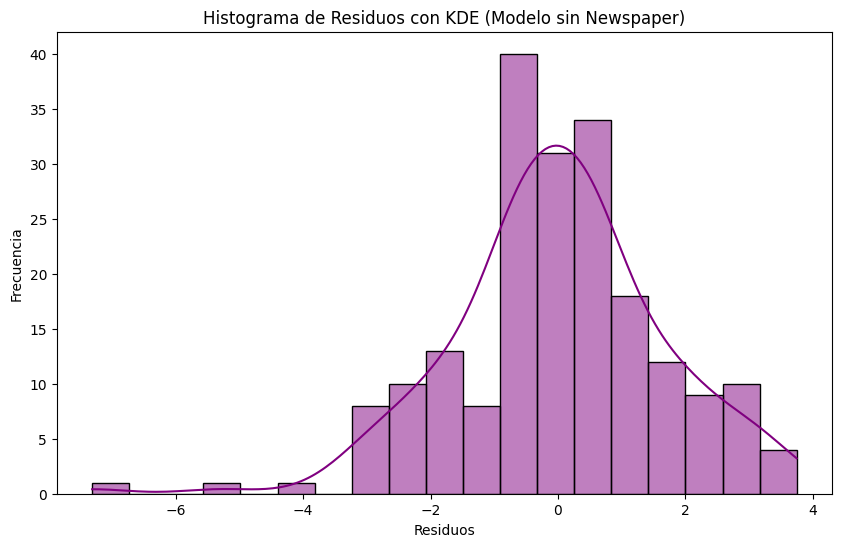

In [87]:
# Calcula los residuos
residuals_no_newspaper = y - y_pred_no_newspaper

# Grafica un histograma con KDE de los residuos.
plt.figure(figsize=(10, 6))
sns.histplot(residuals_no_newspaper, kde=True, color='purple')
plt.title('Histograma de Residuos con KDE (Modelo sin Newspaper)')
plt.xlabel('Residuos')
plt.ylabel('Frecuencia')
plt.show()

### 🔍 **Interpretación del Histograma de Residuos (sin Newspaper)**

Al igual que en el modelo anterior, los residuos del modelo sin 'Newspaper' parecen distribuirse aproximadamente de forma normal, centrados alrededor de cero, aunque con posibles ligeras desviaciones. Esto apoya el supuesto de normalidad de los residuos.

### 6.3. Homocedasticidad (sin Newspaper)

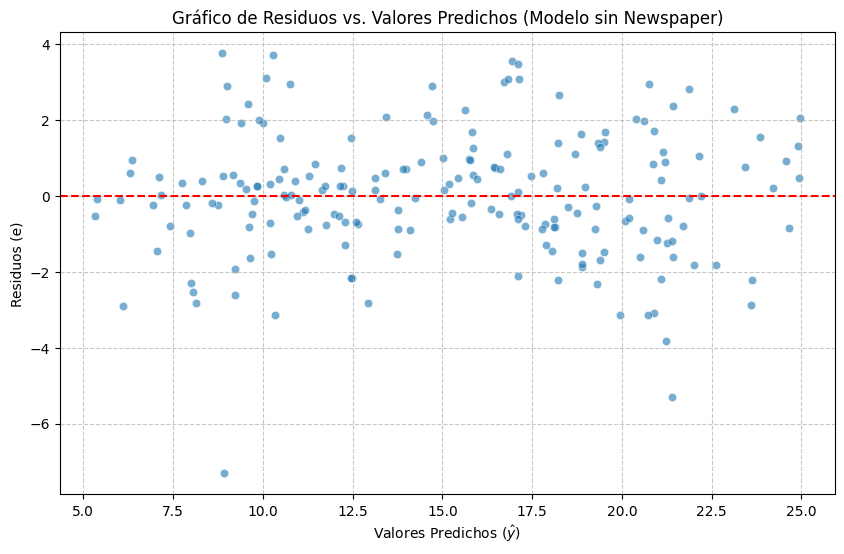

In [95]:
import matplotlib.pyplot as plt
import seaborn as sns

# Grafica los residuos contra los valores predichos.
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_pred_no_newspaper, y=residuals_no_newspaper, alpha=0.6)
plt.axhline(y=0, color='red', linestyle='--')
plt.title('Gráfico de Residuos vs. Valores Predichos (Modelo sin Newspaper)')
plt.xlabel(r'Valores Predichos ($\hat{y}$)')
plt.ylabel('Residuos (e)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

### 🔍 **Interpretación del Gráfico de Residuos vs. Valores Predichos (Modelo sin Newspaper)**

La dispersión de los residuos alrededor de la línea cero en este gráfico no muestra patrones evidentes. Esto sugiere que el supuesto de homocedasticidad se mantiene, indicando que la varianza de los errores es constante a lo largo de los valores predichos.

### 6.4. Q-Q Plot (sin Newspaper)

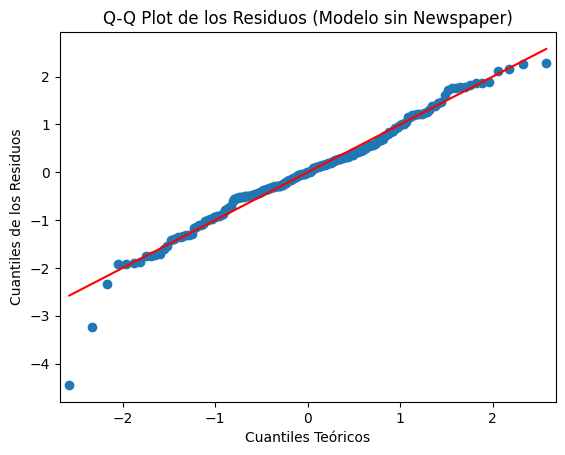

In [89]:
# Q-Q Plot de los residuos
sm.qqplot(residuals_no_newspaper, line='s', fit=True)
plt.title('Q-Q Plot de los Residuos (Modelo sin Newspaper)')
plt.xlabel('Cuantiles Teóricos')
plt.ylabel('Cuantiles de los Residuos')
plt.show()

### 🔍 **Interpretación del Gráfico Cuantil por Cuantil (Modelo sin Newspaper)**

Los puntos en el Q-Q Plot se alinean muy cerca de la línea diagonal, lo que confirma que los residuos del modelo sin 'Newspaper' siguen una distribución aproximadamente normal. Esto es consistente con las observaciones del histograma.

### 6.5. Evaluación del Modelo (sin Newspaper)

In [90]:
# Calcular las métricas
mse_no_newspaper = mean_squared_error(y, y_pred_no_newspaper)
rmse_no_newspaper = np.sqrt(mse_no_newspaper)
r2_no_newspaper = r2_score(y, y_pred_no_newspaper)

print_bold("\n### Evaluación del Modelo (sin Newspaper) ###")
print(f"MSE (Error Cuadrático Medio): {mse_no_newspaper:.2f}")
print(f"RMSE (Raíz del Error Cuadrático Medio): {rmse_no_newspaper:.2f}")
print(f"R² (Coeficiente de Determinación): {r2_no_newspaper:.2f}")



### Evaluación del Modelo (sin Newspaper) ###
MSE (Error Cuadrático Medio): 2.71
RMSE (Raíz del Error Cuadrático Medio): 1.65
R² (Coeficiente de Determinación): 0.90


### 🔍 **Interpretación de la Evaluación del Modelo (sin Newspaper)**

Los valores de **MSE**, **RMSE** y **R²** para este modelo (sin 'Newspaper') nos permiten compararlo con el modelo anterior. Un **R²** cercano a 1 indica que el modelo explica una gran parte de la variabilidad de las ventas, y los valores de **MSE** y **RMSE** nos dan una idea del error promedio de las predicciones. Es probable que estos valores sean muy similares o incluso ligeramente mejores que los del modelo con 'Newspaper', dado que la variable eliminada no era significativa.

### 6.6. Visualización de Predicciones (sin Newspaper)

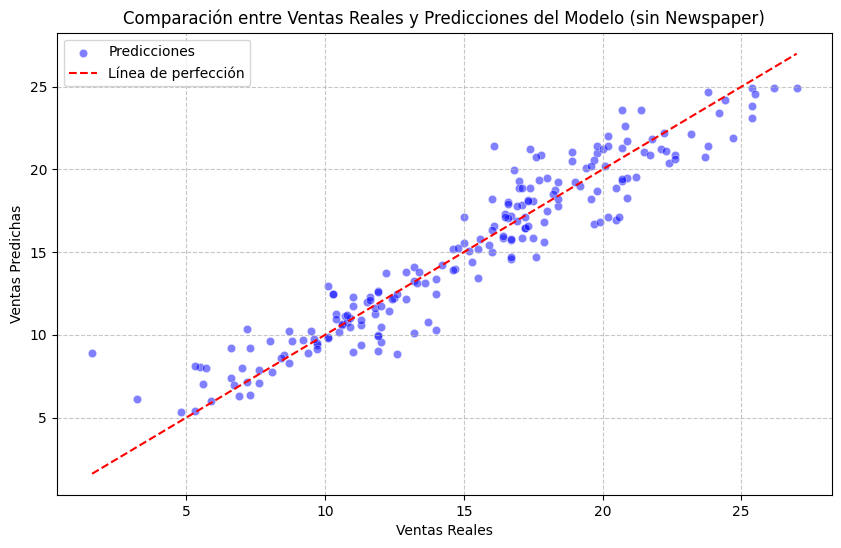

In [91]:
# Visualización de las Predicciones
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y, y=y_pred_no_newspaper, alpha=0.5, color='blue', label='Predicciones')
plt.plot([y.min(), y.max()], [y.min(), y.max()], color='red', linestyle='--', label='Línea de perfección')
plt.title("Comparación entre Ventas Reales y Predicciones del Modelo (sin Newspaper)")
plt.xlabel("Ventas Reales")
plt.ylabel("Ventas Predichas")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

### 🔍 **Interpretación de la Visualización de Predicciones (sin Newspaper)**

La visualización muestra que los puntos de predicción se agrupan estrechamente alrededor de la línea de perfección, lo que indica un buen ajuste del modelo a los datos. Esto refuerza la idea de que la eliminación de 'Newspaper' no ha afectado negativamente la capacidad predictiva del modelo, y posiblemente la ha mejorado ligeramente al reducir el ruido.

### 6.7. Impacto de los Atributos en el Modelo (P-values, sin Newspaper)

In [92]:
# Para statsmodels, necesitamos añadir explícitamente una constante para el intercepto
X_scaled_sm_no_newspaper = sm.add_constant(X_scaled_no_newspaper)

# Crear y ajustar el modelo OLS (Ordinary Least Squares)
model_sm_no_newspaper = sm.OLS(y, X_scaled_sm_no_newspaper)
results_sm_no_newspaper = model_sm_no_newspaper.fit()

print_bold("\n### Resumen del Modelo (Statsmodels) para P-values (sin Newspaper) ###")
print(results_sm_no_newspaper.summary())



### Resumen del Modelo (Statsmodels) para P-values (sin Newspaper) ###
                            OLS Regression Results                            
Dep. Variable:                  Sales   R-squared:                       0.903
Model:                            OLS   Adj. R-squared:                  0.902
Method:                 Least Squares   F-statistic:                     912.7
Date:                Mon, 27 Apr 2026   Prob (F-statistic):          2.39e-100
Time:                        03:19:57   Log-Likelihood:                -383.34
No. Observations:                 200   AIC:                             772.7
Df Residuals:                     197   BIC:                             782.6
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------

### 🔍 **Interpretación de los Valores p (P-values, Modelo sin Newspaper)**

Al observar la tabla de resultados de `statsmodels` (columna `P>|t|`) para el modelo sin 'Newspaper', podemos resumir la significancia estadística de cada variable:

| Variable   | P-value | Significancia Estadística |
|:-----------|:--------|:--------------------------|
| `const`    | 0.000   | Significativo (p < 0.05)  |
| `TV`       | 0.000   | Significativo (p < 0.05)  |
| `Radio`    | 0.000   | Significativo (p < 0.05)  |

**Conclusión:** En este modelo simplificado, tanto la inversión en **Televisión** como en **Radio** siguen siendo estadísticamente significativas para predecir las ventas. La eliminación de la variable no significativa 'Newspaper' ha permitido un modelo más limpio sin sacrificar poder predictivo, y confirmando la relevancia de las variables restantes.

##7. Conclusiones.

¿Cuál de los tres modelos construidos fue el mejor?
¿Cuál fue el atributo que mas influencia tiene en las ventas?


### 🔍 **¿Cuál de los tres modelos construidos fue el mejor?**

El **Modelo 3 (sin la variable `Newspaper`)** fue el mejor. Aunque el Modelo 1 (con todas las variables) y el Modelo 3 tuvieron métricas de evaluación (MSE, RMSE, R²) prácticamente idénticas (R² de 0.90 en ambos casos), el Modelo 3 es preferible por las siguientes razones:

*   **Limpieza:** Es un modelo más simple, utilizando menos variables predictoras (`TV` y `Radio`).
*   **Significancia Estadística:** En el Modelo 3, todas las variables (`TV` y `Radio`) son estadísticamente significativas (p-value < 0.05), lo que indica que tienen un impacto real y no aleatorio en las ventas. En contraste, la variable `Newspaper` en el Modelo 1 no era estadísticamente significativa (p-value = 0.954), lo que sugiere que no contribuía de manera significativa a la predicción de ventas.

La eliminación de la variable `Newspaper` no afectó negativamente el poder predictivo del modelo y resultó en un modelo más robusto y fácil de interpretar.

### 🔍 **¿Cuál fue el atributo que más influencia tiene en las ventas?**

El atributo con mayor influencia en las ventas es la inversión en publicidad **`TV`** (Televisión). Esto se ha demostrado consistentemente a lo largo del análisis:

*   **Análisis de Correlación:** `TV` mostró la correlación más fuerte con `Sales` (0.90), como se observó en el heatmap.
*   **Coeficientes Escalados:** El coeficiente escalado de `TV` fue el más alto (aproximadamente 4.66) en ambos modelos (con y sin `Newspaper`), lo que indica que un cambio de una desviación estándar en la inversión en TV resulta en el mayor cambio de desviaciones estándar en las ventas, en comparación con `Radio`.
*   **P-values:** `TV` fue altamente estadísticamente significativo (p-value < 0.000) en todos los modelos, confirmando su fuerte relación con las ventas.

#Referencias
Khan, A. (2025). Homoscedasticity in Regression. GeeksforGeeks. https://www.geeksforgeeks.org/machine-learning/homoscedasticity-in-regression/

Saxena, P. (2026). Quantile-Quantile Plots. GeeksforGeeks. https://www.geeksforgeeks.org/data-analysis/quantile-quantile-plots/
